In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import reservoirpy as rpy
rpy.verbosity(0)
from tqdm import tqdm
from RCENSO import *
%config InlineBackend.figure_format = 'retina'

## 1. Data Loading and DESN Configuration

In [2]:
ds = xr.open_dataset('data/oras5_indices_1958-2025.nc', engine='netcdf4').sel(time=slice('1958-01', '2024-12'))
ds = standardize_time_to_month_start(ds)
ds = ds[['Nino34', 'WWV'] + [v for v in ds.data_vars if v not in ('Nino34', 'WWV')]]
TS = ds.to_array().values.T
tl = 42 * 12  # training length: 1958-1999
TS_TP = pack_TS_anualTP(TS, order=2)
t = np.arange(len(ds.time))

hypers = {
    'units': [20000, 12000],
    'lr': [1, 1],
    'sr': [1, 1],
    'rc_connectivity': [0, 0],
    'input_connectivity': [0.1, 0.1],
    'input_scaling': [1.0, 1.0],
    'ridge': 5e-6,
    'noise_rc': [0.05, 0],
    'noise_in': [0, 0],
    'seed': None,
    'deep': True,
    'deep_ip_list': [True, False],
}
steps = 101

## 2. Run DESN Error Growth Experiment

In [3]:
init_perturbs = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 5e-2, 5e-1, 1, 2, 3]
nmembers = 3

desn_error_ratios_list = []
for init_perturb in init_perturbs:
    result = fast_stochastic_ESN_error_growth(
        TS_TP, hypers=hypers, tl=tl, steps=steps,
        perturb_dim=10, nmembers=nmembers, init_perturb=init_perturb,
    )
    desn_error_ratios_list.append(result)

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Stochastic Simulating: 100%|██████████| 3/3 [1:28:55<00:00, 1778.47s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Stochastic Simulating: 100%|██████████| 3/3 [1:35:31<00:00, 1910.34s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


...

Stochastic Simulating: 100%|██████████| 3/3 [54:19<00:00, 1086.45s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Stochastic Simulating: 100%|██████████| 3/3 [54:06<00:00, 1082.19s/it]


Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Stochastic Simulating: 100%|██████████| 3/3 [54:07<00:00, 1082.46s/it]


## 3. Plot Error Saturation Steps

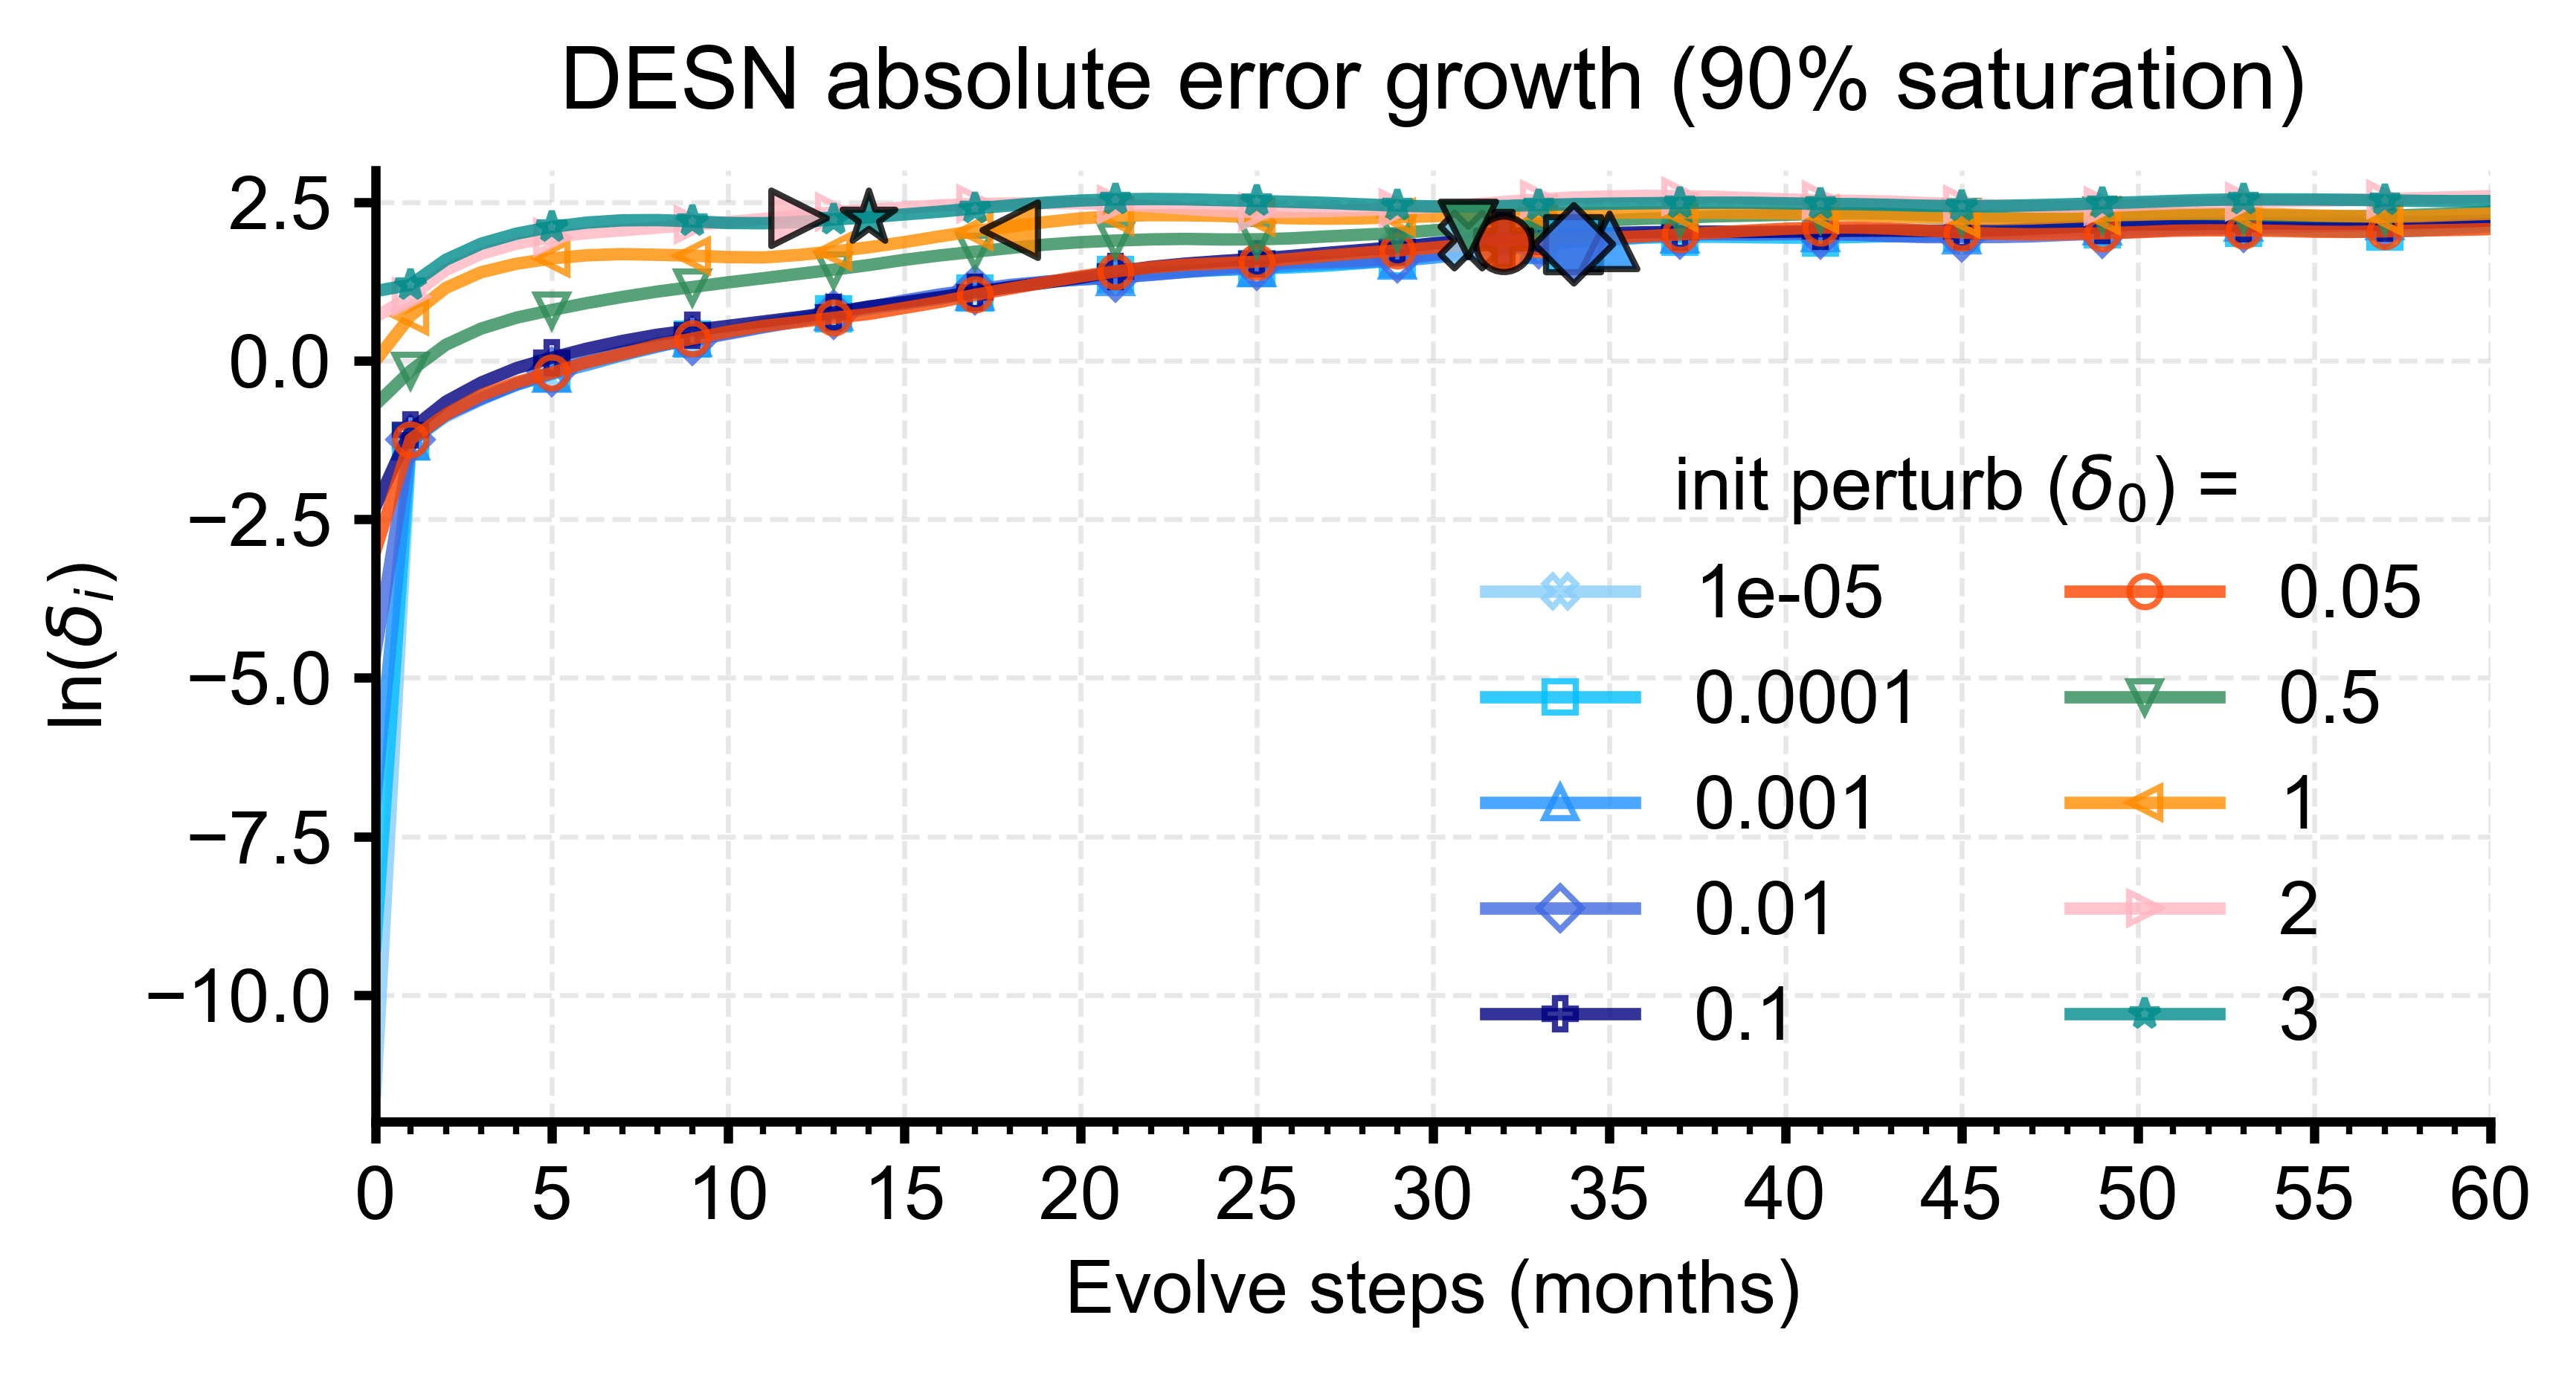

In [4]:
colors = [
    'LightSkyBlue', 'DeepSkyBlue', 'DodgerBlue', 'RoyalBlue', 'Navy',
    'orangered', 'seagreen', 'darkorange', 'lightpink', 'darkcyan',
]
markers = ['X', 's', '^', 'D', 'P', 'o', 'v', '<', '>', '*']
plot_steps = 61

fig, ax = plt.subplots(figsize=(6, 3.3), dpi=300)

for idx, init_perturb in enumerate(init_perturbs):
    vals = np.log(desn_error_ratios_list[idx]['mean'][:plot_steps] * init_perturb)
    sat_val = 0.90 * np.mean(vals[40:])
    above = np.where(vals >= sat_val)[0]
    sat_step = int(above[0]) if above.size else plot_steps - 1

    c = colors[idx % len(colors)]
    m = markers[idx % len(markers)]

    # Error growth curve with hollow markers
    ax.plot(
        np.arange(plot_steps), vals,
        color=c, lw=2, alpha=0.8, label=f'{init_perturb}',
        marker=m, markersize=5, markevery=slice(1, None, 4),
        markerfacecolor='none', markeredgecolor=c, markeredgewidth=1,
    )
    # Mark saturation point
    ax.scatter(sat_step, sat_val,
               color=c, marker=m, edgecolors='k', s=80, zorder=5, alpha=0.8)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_xlim(0, plot_steps - 1)
ax.set_ylim(-12, 3)
ax.set_xlabel('Evolve steps (months)', fontsize=12)
ax.set_ylabel(r'ln($\delta_i$)', fontsize=12)
ax.set_title('DESN absolute error growth (90% saturation)', fontsize=14, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, plot_steps, 5))
plt.xticks(np.arange(0, plot_steps, 1), minor=True)
leg = ax.legend(
    title=r'init perturb ($\delta_0$) =',
    ncol=2, fontsize=12, title_fontsize=12,
    loc='lower right', frameon=False,
)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()